In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from collections import namedtuple, defaultdict
import json
import numpy as np
from scipy import stats
import csv

In [10]:
prompt_dir = Path('/data/projects/AgentScaling/adaptive_agentic_serving/input')
llama3_8B_Instruct_dir = Path('1p1d_llama3-8B-Instruct')
Qwen3_06B_dir = Path('1p1d_Qwen3-0.6B')
Qwen3_06B_300_200_dir = Path('1p1d_Qwen3-0.6B_300-200')
policies = ['default', 'no_disagg', 'all_disagg', 'adaptive_disagg']

In [3]:
with open(prompt_dir / 'prompt_lengths_10x5.json', 'r') as f:
    lengths_10x5 = json.load(f)
with open(prompt_dir / 'prompt_lengths_40x5.json', 'r') as f:
    lengths_40x5 = json.load(f)

In [11]:
LatencyRecord = namedtuple('LatencyRecord', ['ttft', 'tbt'])
all_iter_indexes = [(i,j) for i in range(10) for j in range(5)]
first_iter_indexes = [(i,0) for i in range(10)]
rest_iter_indexes = [(i,j) for i in range(10) for j in range(1, 5)]

def save_latency_map(latency_map, path):
    def serialize_latency_ms(record: LatencyRecord) -> dict:
        return {
            'ttft_ms': record.ttft.total_seconds() * 1000,
            'tbt_ms': [x.total_seconds() * 1000 for x in record.tbt]
        }
    json_map = {str(k): serialize_latency_ms(v) for k, v in latency_map.items()}
    with open(path, 'w') as f:
        json.dump(json_map, f, indent=2)

def load_latency_map(path):
    with open(path, 'r') as f:
        json_map = json.load(f)

    # 3️⃣ Convert back to latency_map with pd.Timedelta
    latency_map = {}
    for k_str, v in json_map.items():
        # Convert string key back to tuple
        conv_id, inference_id = eval(k_str)  # safe if you control the file
        
        # Convert milliseconds back to pd.Timedelta
        ttft = pd.Timedelta(milliseconds=v['ttft_ms'])
        tbt  = [pd.Timedelta(milliseconds=x) for x in v['tbt_ms']]
        
        # Store as NamedTuple
        latency_map[(conv_id, inference_id)] = LatencyRecord(ttft, tbt)
    return latency_map

def load_latency_maps(path):
    latency_maps = {
        policy: load_latency_map(path / policy / 'latency_map.json')
        for policy in policies if policy != 'adaptive_disagg'
    }
    latency_maps['adaptive_disagg'] = load_latency_map(path / 'adaptive_disagg_rest' / 'latency_map.json')
    return latency_maps

def data_from_latency_maps(latency_maps):
    first_iter_ttfts = {
        policy: np.array([latency_maps[policy][index].ttft.total_seconds()*1000 for index in first_iter_indexes])
        for policy in policies
    }
    normalized_first_iter_ttfts = {
        policy: first_iter_ttfts[policy] / first_iter_ttfts['default']
        for policy in policies
    }
    rest_iter_ttfts = {
        policy: np.array([latency_maps[policy][index].ttft.total_seconds()*1000 for index in rest_iter_indexes])
        for policy in policies
    }
    normalized_rest_iter_ttfts = {
        policy: rest_iter_ttfts[policy] / rest_iter_ttfts['default']
        for policy in policies
    }
    tbts = {
        policy: [time.total_seconds()*1000 for index in latency_maps[policy].keys() for time in latency_maps[policy][index].tbt]
        for policy in policies
    }
    p99_tbts = {
        policy: np.percentile(tbts[policy], 99)
        for policy in policies
    }
    normalized_p99_tbts = {
        policy: p99_tbts[policy] / p99_tbts['default']
        for policy in policies
    }
    max_tbts = {
        policy: max(tbts[policy])
        for policy in policies
    }
    normalized_max_tbts = {
        policy: max_tbts[policy] / max_tbts['default']
        for policy in policies
    }
    return normalized_first_iter_ttfts, normalized_rest_iter_ttfts, normalized_p99_tbts, normalized_max_tbts

def load_e2e_latency_maps(path):
    latency_maps = defaultdict(dict)
    for policy in policies:
        csv_path = path / 'adaptive_disagg_rest' / 'per_step_latency.csv' if policy == 'adaptive_disagg' else path / policy / 'per_step_latency.csv'
        with open(csv_path, 'r') as csvfile:
            reader = csv.DictReader(csvfile)
            for row in reader:
                conv_id = int(row['conv_id'])
                step_id = int(row['step_id'])
                latency_sec = float(row['latency_sec'])
                latency_maps[policy][(conv_id, step_id)] = latency_sec
    normalized_latency_maps = defaultdict(dict)
    for policy in policies:
        for key in latency_maps[policy].keys():
            normalized_latency_maps[policy][key] = latency_maps[policy][key] / latency_maps['default'][key]
    return latency_maps, normalized_latency_maps



In [27]:
PAARSE_DISPATCH = {}
def register(baseline_name):
    def decorator(fn):
        PAARSE_DISPATCH[baseline_name] = fn
        return fn  # IMPORTANT: return the function unchanged
    return decorator

In [28]:
@register("default")
def parse_latency_map_default(base_dir):
    raw_map = defaultdict(list)
    df0 = pd.read_json(base_dir / 'default' / 'prefiller_vllm_core_log.jsonl', lines=True)
    df1 = pd.read_json(base_dir / 'default' / 'decoder_vllm_core_log.jsonl', lines=True)
    for df in [df0, df1]:
        df['latency'] = df['timestamp'].diff()
        df = df[df['request_ids'].apply(lambda x: isinstance(x, list) and len(x) > 0)].reset_index(drop=True)
        df.loc[:, 'conv_id'] = df['request_ids'].apply(lambda lst: [int(x.split('-')[1]) for x in lst])
        df.loc[:, 'iter_id'] = df['request_ids'].apply(lambda lst: [int(x.split('-')[2]) for x in lst])
        for _, row in df.iterrows():
            for conv_id, iter_id in zip(row['conv_id'], row['iter_id']):
                raw_map[(conv_id, iter_id)].append(row['latency'])
    latency_map = {key: LatencyRecord(latencies[0], latencies[1:]) for key, latencies in raw_map.items()}
    save_latency_map(latency_map, base_dir / 'default' / 'latency_map.json')

In [55]:
@register("no_disagg")
def parse_latency_map_no_disagg(base_dir):
    raw_map = defaultdict(list)
    df0 = pd.read_json(base_dir / 'no_disagg' / 'prefiller_vllm_core_log.jsonl', lines=True)
    df1 = pd.read_json(base_dir / 'no_disagg' / 'decoder_vllm_core_log.jsonl', lines=True)
    for df in [df0, df1]:
        df['latency'] = df['timestamp'].diff()
        df = df[df['request_ids'].apply(lambda x: isinstance(x, list) and len(x) > 0)].reset_index(drop=True)
        df.loc[:, 'conv_id'] = df['request_ids'].apply(lambda lst: [int(x.split('-')[1]) for x in lst])
        df.loc[:, 'iter_id'] = df['request_ids'].apply(lambda lst: [int(x.split('-')[2]) for x in lst])
        for _, row in df.iterrows():
            for conv_id, iter_id in zip(row['conv_id'], row['iter_id']):
                raw_map[(conv_id, iter_id)].append(row['latency'])
    latency_map = {key: LatencyRecord(latencies[0], latencies[1:]) for key, latencies in raw_map.items()}
    save_latency_map(latency_map, base_dir / 'no_disagg' / 'latency_map.json')

In [56]:
@register("all_disagg")
def parse_latency_map_all_disagg(base_dir):
    raw_map = defaultdict(list)
    df0 = pd.read_json(base_dir / 'all_disagg' / 'prefiller_vllm_core_log.jsonl', lines=True)
    df1 = pd.read_json(base_dir / 'all_disagg' / 'decoder_vllm_core_log.jsonl', lines=True)
    for idx, df in enumerate([df0, df1]):
        df['latency'] = df['timestamp'].diff()
        df = df[df['request_ids'].apply(lambda x: isinstance(x, list) and len(x) > 0)].reset_index(drop=True)
        df.loc[:, 'conv_ids'] = df['request_ids'].apply(lambda lst: [int(x.split('-')[1]) for x in lst])
        df.loc[:, 'iter_ids'] = df['request_ids'].apply(lambda lst: [int(x.split('-')[2]) for x in lst])
        if idx == 0:
            df0 = df
        else:
            df1 = df
    subdf0 = df0.explode(['request_ids', 'conv_ids', 'iter_ids'], ignore_index=True)
    subdf1 = (
        df1
        .explode(['request_ids', 'conv_ids', 'iter_ids'], ignore_index=True)
        .drop_duplicates(subset='request_ids', keep='first')
    )
    aligned = (
        subdf1
        .set_index('request_ids')
        .loc[subdf0['request_ids']]
    )
    subdf0['latency'] = (
        subdf0['latency'].to_numpy()
        + (
            aligned['timestamp'].to_numpy()
            - aligned['latency'].to_numpy()
            - subdf0['timestamp'].to_numpy()
        )
    )
    for _, row in subdf0.iterrows():
        raw_map[(row['conv_ids'], row['iter_ids'])].append(row['latency'])
    for _, row in df1.iterrows():
        for conv_id, iter_id in zip(row['conv_ids'], row['iter_ids']):
            raw_map[(conv_id, iter_id)].append(row['latency'])
    latency_map = {key: LatencyRecord(latencies[0], latencies[1:]) for key, latencies in raw_map.items()}
    save_latency_map(latency_map, base_dir / 'all_disagg' / 'latency_map.json')

In [57]:
@register("adaptive_disagg")
def parse_latency_map_adaptive_disagg(base_dir):
    raw_map = defaultdict(list)
    df0 = pd.read_json(base_dir / 'adaptive_disagg_first' / 'prefiller_vllm_core_log.jsonl', lines=True)
    df1 = pd.read_json(base_dir / 'adaptive_disagg_first' / 'decoder_vllm_core_log.jsonl', lines=True)
    for idx, df in enumerate([df0, df1]):
        df['latency'] = df['timestamp'].diff()
        df = df[df['request_ids'].apply(lambda x: isinstance(x, list) and len(x) > 0)].reset_index(drop=True)
        df.loc[:, 'conv_ids'] = df['request_ids'].apply(lambda lst: [int(x.split('-')[1]) for x in lst])
        df.loc[:, 'iter_ids'] = df['request_ids'].apply(lambda lst: [int(x.split('-')[2]) for x in lst])
        if idx == 0:
            df0 = df
        else:
            df1 = df
    subdf0 = df0.explode(['request_ids', 'conv_ids', 'iter_ids'], ignore_index=True)
    subdf1 = (
        df1
        .explode(['request_ids', 'conv_ids', 'iter_ids'], ignore_index=True)
        .drop_duplicates(subset='request_ids', keep='first')
    )
    aligned = (
        subdf1
        .set_index('request_ids')
        .loc[subdf0['request_ids']]
    )
    subdf0['latency'] = (
        subdf0['latency'].to_numpy()
        + (
            aligned['timestamp'].to_numpy()
            - aligned['latency'].to_numpy()
            - subdf0['timestamp'].to_numpy()
        )
    )
    for _, row in subdf0.iterrows():
        raw_map[(row['conv_ids'], row['iter_ids'])].append(row['latency'])


    df = pd.read_json(base_dir / 'adaptive_disagg_rest' / 'decoder_vllm_core_log.jsonl', lines=True)
    df['latency'] = df['timestamp'].diff()
    df = df[df['request_ids'].apply(lambda x: isinstance(x, list) and len(x) > 0)].reset_index(drop=True)
    df.loc[:, 'conv_ids'] = df['request_ids'].apply(lambda lst: [int(x.split('-')[1]) for x in lst])
    df.loc[:, 'iter_ids'] = df['request_ids'].apply(lambda lst: [int(x.split('-')[2]) for x in lst])
    visited = [False] * len(subdf0)
    for _, row in df.iterrows():
        for conv_id, iter_id in zip(row['conv_ids'], row['iter_ids']):
            if not visited[conv_id]:
                visited[conv_id] = True
            else:
                raw_map[(conv_id, iter_id)].append(row['latency'])
    latency_map = {key: LatencyRecord(latencies[0], latencies[1:]) for key, latencies in raw_map.items()}
    save_latency_map(latency_map, base_dir / 'adaptive_disagg_rest' / 'latency_map.json')


In [58]:
for policy in policies:
    fn = PAARSE_DISPATCH[policy]
    fn(Qwen3_06B_300_200_dir)

In [3]:
all_iter_indexes = [(i,j) for i in range(10) for j in range(5)]
first_iter_indexes = [(i,0) for i in range(10)]
rest_iter_indexes = [(i,j) for i in range(10) for j in range(1, 5)]

In [23]:
def plot(normalized_e2e_latency_maps, normalized_first_iter_ttfts, normalized_rest_iter_ttfts, normalized_p99_tbts, normalized_max_tbts):
    fig, axs = plt.subplots(1, 4, figsize=(25, 5))
    
    # Plot normalized results
    p99_e2e_latencies = {
        policy: np.percentile(list(normalized_e2e_latency_maps[policy].values()), 99)
        for policy in policies[1:]
    }
    x = np.arange(5)
    xlabels = ['p99 e2e latency', 'First Iteration TTFT', 'Rest Iteration TTFT', 'p99 TBT', 'Max TBT']
    data = [
        [
            p99_e2e_latencies[policy],
            stats.hmean(normalized_first_iter_ttfts[policy]), 
            stats.hmean(normalized_rest_iter_ttfts[policy]), 
            normalized_p99_tbts[policy], 
            normalized_max_tbts[policy]
        ]
        for policy in policies[1:]
    ]
    for i, policy in enumerate(policies[1:]):
        axs[0].bar(x-0.2+i*0.2, data[i], label=policy, width=0.2)
    axs[0].set_title('Normalized Results')
    axs[0].set_xticks(x, xlabels)
    axs[0].legend()

    # Plot normalized e2e latency maps
    x = np.arange(50)
    data = [
        [
            normalized_e2e_latency_maps[policy][index]
            for index in all_iter_indexes
        ]
        for policy in policies[1:]
    ]
    for i, policy in enumerate(policies[1:]):
        axs[1].scatter(x, data[i], label=policy)
        # axs[1].bar(x-0.2+i*0.2, data[i], label=policy, width=0.2)
    axs[1].set_title('Normalized E2E Latency Maps')
    axs[1].legend()

    # Plot first iteration ttfts
    x = np.arange(10)
    for policy in policies[1:]:
        axs[2].scatter(x, normalized_first_iter_ttfts[policy], label=policy)
    axs[2].legend()
    axs[2].set_title('Normalized First Iteration TTFT')
    axs[2].set_xlabel('Conversation Index')
    axs[2].set_ylabel('Normalized TTFT')

    # Plot rest iteration ttfts
    x = np.arange(40)
    for policy in policies[1:]:
        axs[3].scatter(x, normalized_rest_iter_ttfts[policy], label=policy)
    axs[3].legend()
    axs[3].set_title('Normalized Rest Iteration TTFT')
    axs[3].set_xlabel('Conversation Index')
    axs[3].set_ylabel('Normalized TTFT')


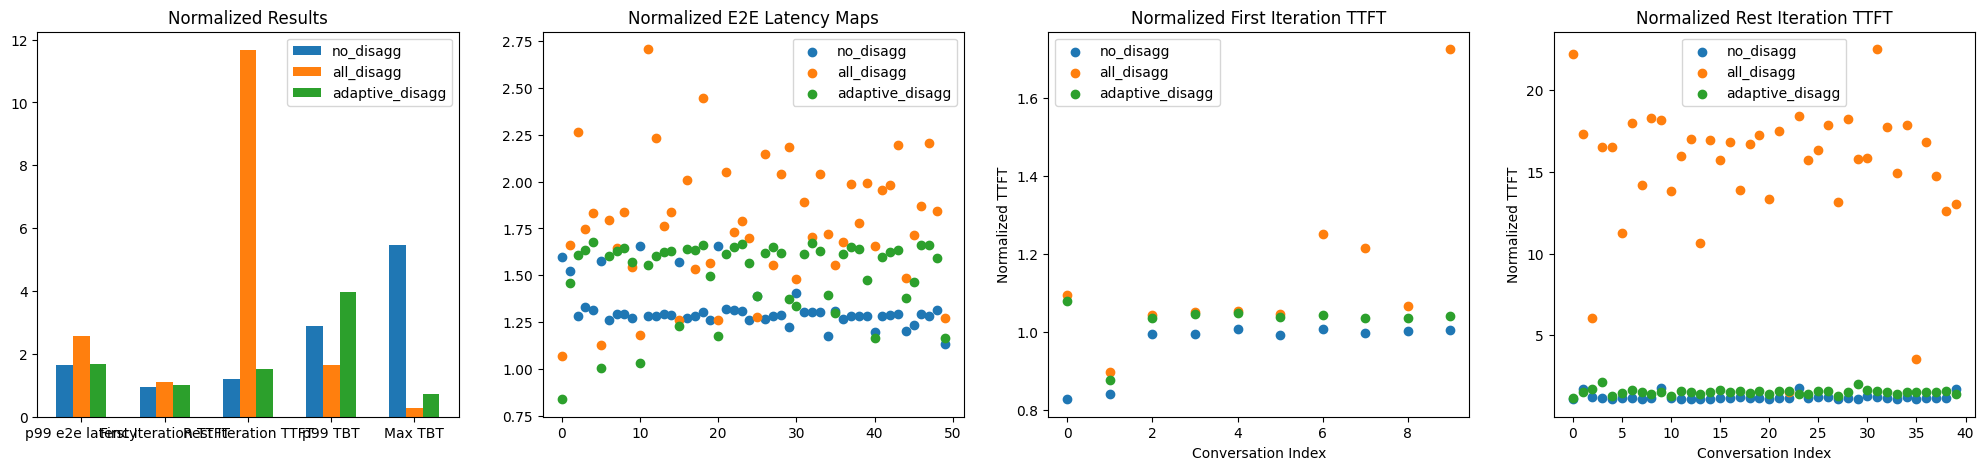

In [24]:
latency_maps = load_latency_maps(llama3_8B_Instruct_dir)
e2e_latency_maps, normalized_e2e_latency_maps = load_e2e_latency_maps(llama3_8B_Instruct_dir)
normalized_first_iter_ttfts, normalized_rest_iter_ttfts, normalized_p99_tbts, normalized_max_tbts = data_from_latency_maps(latency_maps)
plot(normalized_e2e_latency_maps, normalized_first_iter_ttfts, normalized_rest_iter_ttfts, normalized_p99_tbts, normalized_max_tbts)

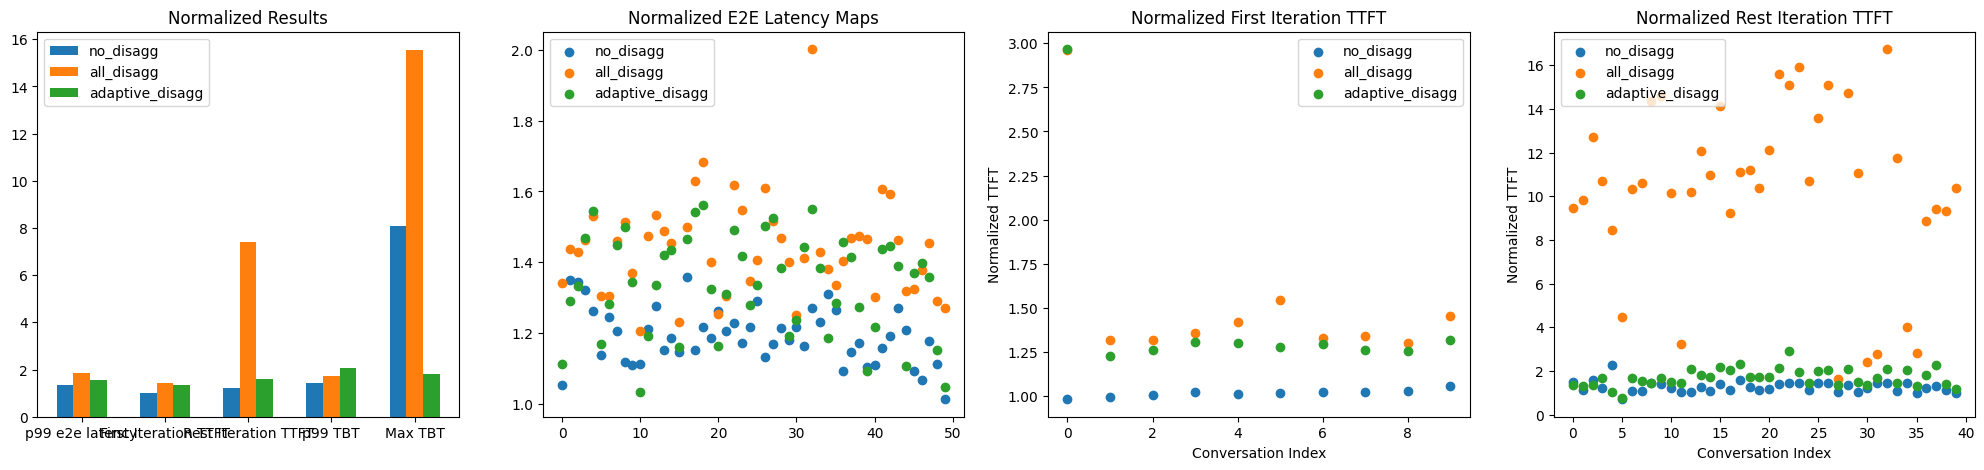

In [25]:
latency_maps = load_latency_maps(Qwen3_06B_dir)
e2e_latency_maps, normalized_e2e_latency_maps = load_e2e_latency_maps(Qwen3_06B_dir)
normalized_first_iter_ttfts, normalized_rest_iter_ttfts, normalized_p99_tbts, normalized_max_tbts = data_from_latency_maps(latency_maps)
plot(normalized_e2e_latency_maps, normalized_first_iter_ttfts, normalized_rest_iter_ttfts, normalized_p99_tbts, normalized_max_tbts)

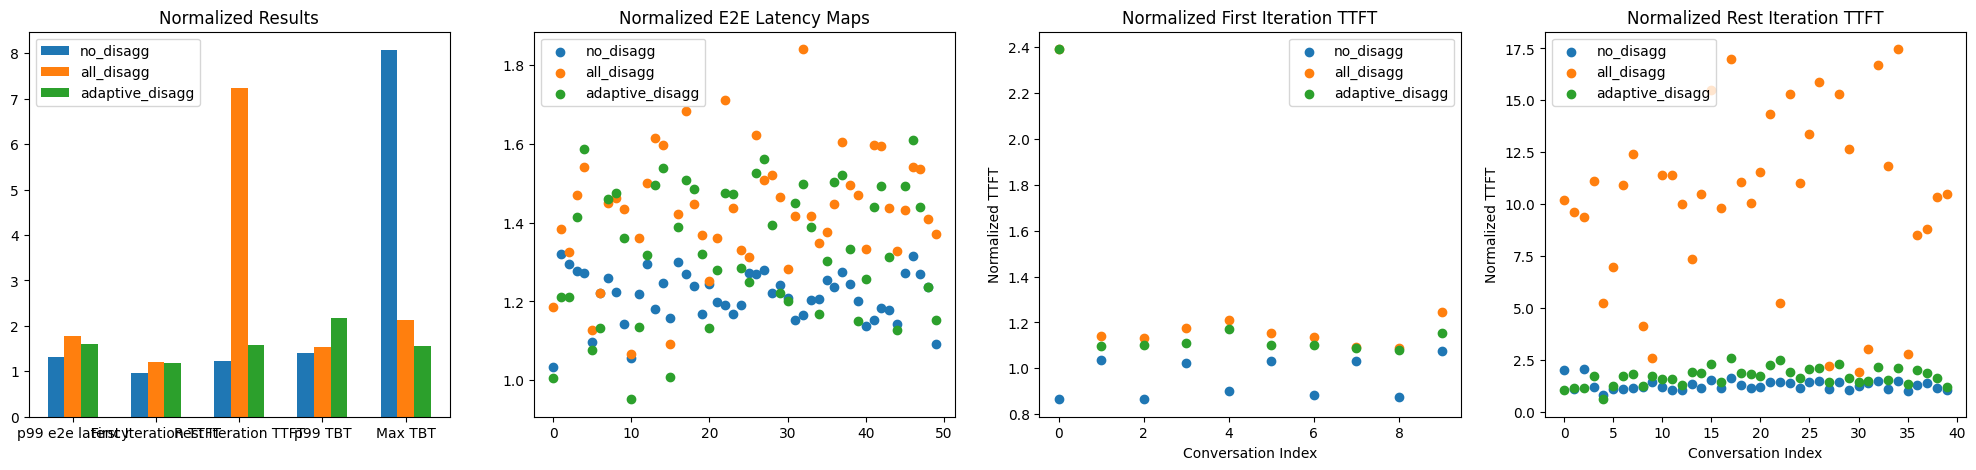

In [26]:
latency_maps = load_latency_maps(Qwen3_06B_300_200_dir)
e2e_latency_maps, normalized_e2e_latency_maps = load_e2e_latency_maps(Qwen3_06B_300_200_dir)
normalized_first_iter_ttfts, normalized_rest_iter_ttfts, normalized_p99_tbts, normalized_max_tbts = data_from_latency_maps(latency_maps)
plot(normalized_e2e_latency_maps, normalized_first_iter_ttfts, normalized_rest_iter_ttfts, normalized_p99_tbts, normalized_max_tbts)